In [33]:
!pip install --quiet xgboost

In [34]:
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

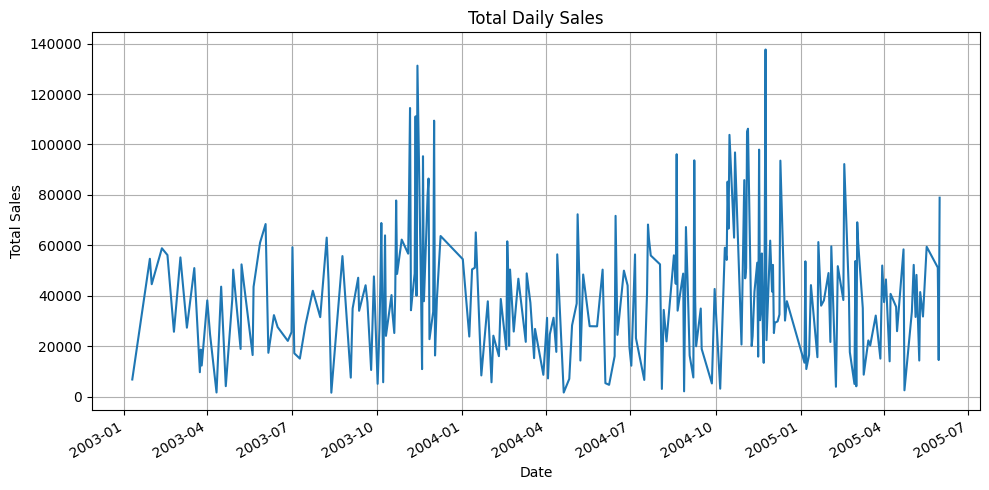

In [46]:
# Calculate daily total sales
daily_total_sales = daily_sales.groupby('ds')['y'].sum()

# Plot the total sales per day
plt.figure(figsize=(10, 5))
daily_total_sales.plot()
plt.title("Total Daily Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid()
plt.tight_layout()
plt.show()

In [75]:
# Initialize and fit Prophet model
model = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
model.fit(daily_sales)


01:38:42 - cmdstanpy - INFO - Chain [1] start processing
01:38:42 - cmdstanpy - INFO - Chain [1] done processing


In [76]:
# Forecast for next 90 days
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)


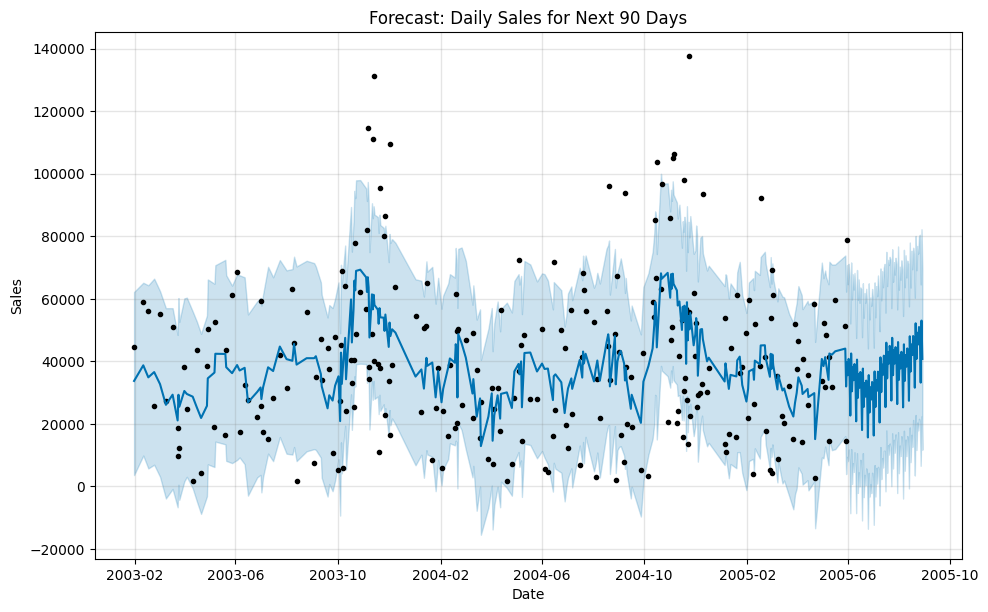

In [77]:
fig1 = model.plot(forecast)
plt.title("Forecast: Daily Sales for Next 90 Days")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()


01:45:38 - cmdstanpy - INFO - Chain [1] start processing
01:45:38 - cmdstanpy - INFO - Chain [1] done processing


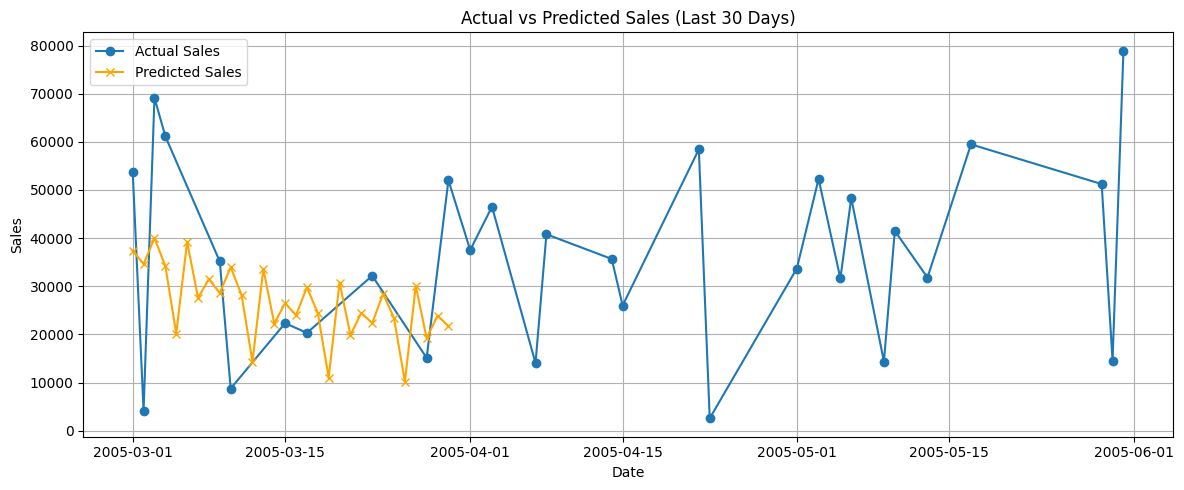

In [78]:
# Train-test split
train = daily_sales[:-30]
test = daily_sales[-30:]

# Refit model on train only
model = Prophet()
model.fit(train)

# Forecast for test period
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Compare predictions
predicted = forecast[['ds', 'yhat']].tail(30)
actual = test[['ds', 'y']].reset_index(drop=True)

# Plot actual vs predicted
plt.figure(figsize=(12, 5))
plt.plot(actual['ds'], actual['y'], label='Actual Sales', marker='o')
plt.plot(predicted['ds'], predicted['yhat'], label='Predicted Sales', marker='x', color='orange')
plt.title("Actual vs Predicted Sales (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [47]:
# Feature Engineering: Create datetime-based features
daily_sales['day'] = daily_sales['ds'].dt.day
daily_sales['month'] = daily_sales['ds'].dt.month
daily_sales['year'] = daily_sales['ds'].dt.year
daily_sales['day_of_week'] = daily_sales['ds'].dt.dayofweek

# Optional: Create lag features (previous day's sales)
daily_sales['lag_1'] = daily_sales['y'].shift(1)
daily_sales = daily_sales.dropna()  # Remove NaN rows created by lag

# Preview engineered data
daily_sales.head()

,ds,y,day,month,year,day_of_week,lag_1
3,2003-01-29,54702.00,29,1,2003,2,6864.05
4,2003-01-31,44621.96,31,1,2003,4,54702.00
5,2003-02-11,58871.11,11,2,2003,1,44621.96
6,2003-02-17,56181.32,17,2,2003,0,58871.11
7,2003-02-24,25783.76,24,2,2003,0,56181.32


In [48]:
# Define feature columns and target
X = daily_sales[['day', 'month', 'year', 'day_of_week', 'lag_1']]
y = daily_sales['y']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Preview shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((199, 5), (50, 5), (199,), (50,))

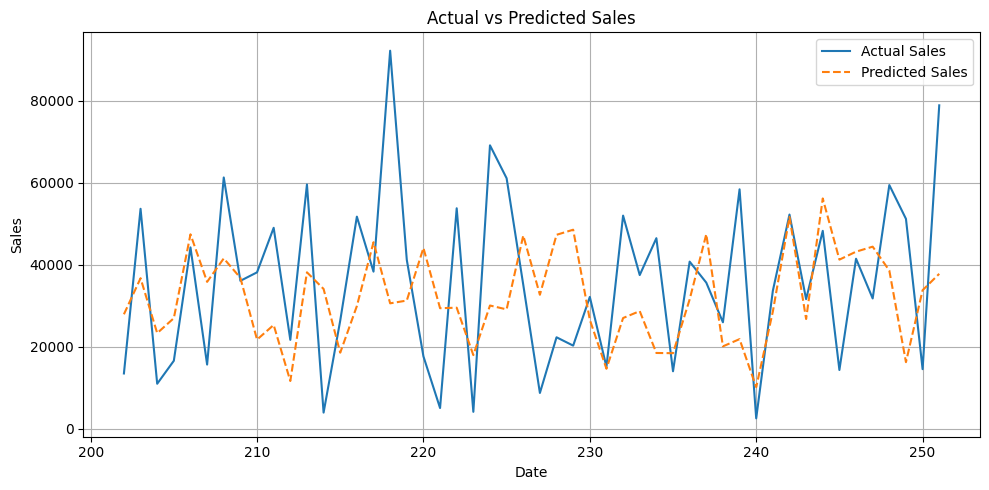

In [73]:
# Initialize and train the XGBoost model
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05)
model_xgb.fit(X_train, y_train)

# Make predictions
y_pred = model_xgb.predict(X_test)

# Plot predicted vs actual
plt.figure(figsize=(10,5))
plt.plot(y_test.index, y_test, label="Actual Sales")
plt.plot(y_test.index, y_pred, label="Predicted Sales", linestyle='--')
plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [50]:
# Evaluate performance using MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
# Compute RMSE manually if 'squared' argument is not supported
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Root Mean Squared Error: {rmse}")

Mean Absolute Error: 17521.4226453125
Root Mean Squared Error: 21449.306331326206


In [51]:
# Create future dates (next 30 days, for example)
future_dates = pd.date_range(daily_sales['ds'].max(), periods=31, freq='D')
future_features = pd.DataFrame({
    'day': future_dates.day,
    'month': future_dates.month,
    'year': future_dates.year,
    'day_of_week': future_dates.dayofweek,
    'lag_1': daily_sales['y'].iloc[-1]  # Using last available sales data as lag
})

# Predict future sales
future_sales = model_xgb.predict(future_features)

# Show predicted future sales
future_sales


array([36457.984, 42754.402, 40743.586, 36579.863, 41977.34 , 44452.19 ,
       57918.887, 54855.086, 44138.84 , 32658.67 , 31194.854, 37966.637,
       40013.176, 47645.74 , 48059.78 , 44048.535, 33991.758, 32442.21 ,
       30236.994, 30107.791, 38420.36 , 42499.777, 39379.445, 29502.268,
       31277.096, 24749.49 , 27762.338, 39906.81 , 41320.703, 32455.291,
       20211.424], dtype=float32)

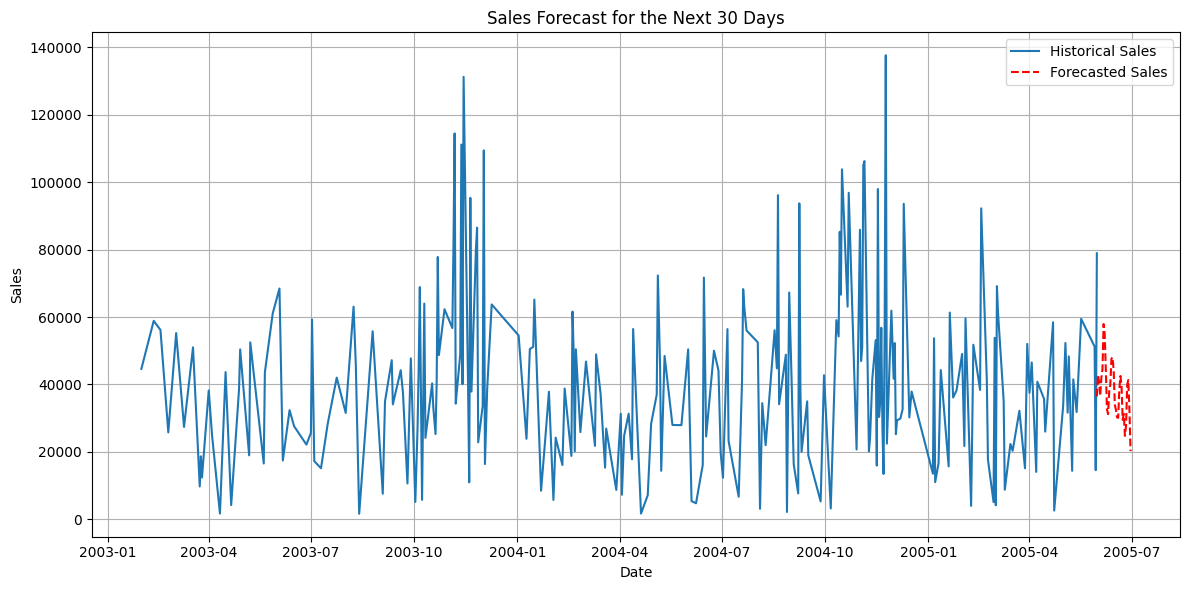

In [72]:
# Plot future sales predictions
plt.figure(figsize=(12, 6))
plt.plot(daily_sales['ds'], daily_sales['y'], label="Historical Sales")
plt.plot(future_dates, future_sales, label="Forecasted Sales", linestyle='--', color='red')
plt.title("Sales Forecast for the Next 30 Days")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [53]:
# Create datetime-based features
daily_sales['day'] = daily_sales['ds'].dt.day
daily_sales['month'] = daily_sales['ds'].dt.month
daily_sales['year'] = daily_sales['ds'].dt.year
daily_sales['day_of_week'] = daily_sales['ds'].dt.dayofweek

# Lag feature: previous day's sales
daily_sales['lag_1'] = daily_sales['y'].shift(1)
daily_sales = daily_sales.dropna()  # Remove NaN rows created by lag

# Preview the data
daily_sales.head()


,ds,y,day,month,year,day_of_week,lag_1
4,2003-01-31,44621.96,31,1,2003,4,54702.00
5,2003-02-11,58871.11,11,2,2003,1,44621.96
6,2003-02-17,56181.32,17,2,2003,0,58871.11
7,2003-02-24,25783.76,24,2,2003,0,56181.32
8,2003-03-03,55245.02,3,3,2003,0,25783.76


In [54]:
# Define features and target for daily prediction
X_daily = daily_sales[['day', 'month', 'year', 'day_of_week', 'lag_1']]
y_daily = daily_sales['y']

# Split into train and test sets
X_train_daily, X_test_daily, y_train_daily, y_test_daily = train_test_split(X_daily, y_daily, test_size=0.2, shuffle=False)

# Preview the split shapes
X_train_daily.shape, X_test_daily.shape, y_train_daily.shape, y_test_daily.shape


((198, 5), (50, 5), (198,), (50,))

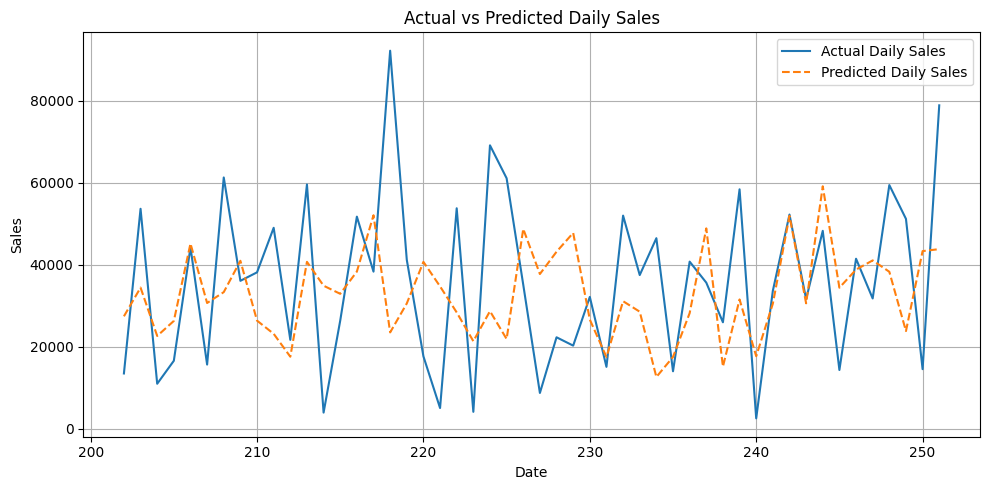

In [71]:
# Train XGBoost model for daily prediction
model_xgb_daily = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05)
model_xgb_daily.fit(X_train_daily, y_train_daily)

# Predict sales for the test set
y_pred_daily = model_xgb_daily.predict(X_test_daily)

# Plot predicted vs actual sales (daily)
plt.figure(figsize=(10, 5))
plt.plot(y_test_daily.index, y_test_daily, label="Actual Daily Sales")
plt.plot(y_test_daily.index, y_pred_daily, label="Predicted Daily Sales", linestyle='--')
plt.title("Actual vs Predicted Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [56]:
# Aggregate sales data by week (weekly predictions)
daily_sales['week'] = daily_sales['ds'].dt.isocalendar().week
weekly_sales = daily_sales.groupby(['year', 'week'], as_index=False)['y'].sum()

# Feature Engineering for weekly data
X_weekly = weekly_sales[['year', 'week']]
X_weekly['day_of_week'] = 0  # Dummy variable for the day of the week (we’ll ignore this for weekly)
y_weekly = weekly_sales['y']

# Split into train and test sets for weekly prediction
X_train_weekly, X_test_weekly, y_train_weekly, y_test_weekly = train_test_split(X_weekly, y_weekly, test_size=0.2, shuffle=False)

# Preview the split shapes
X_train_weekly.shape, X_test_weekly.shape, y_train_weekly.shape, y_test_weekly.shape


((90, 3), (23, 3), (90,), (23,))

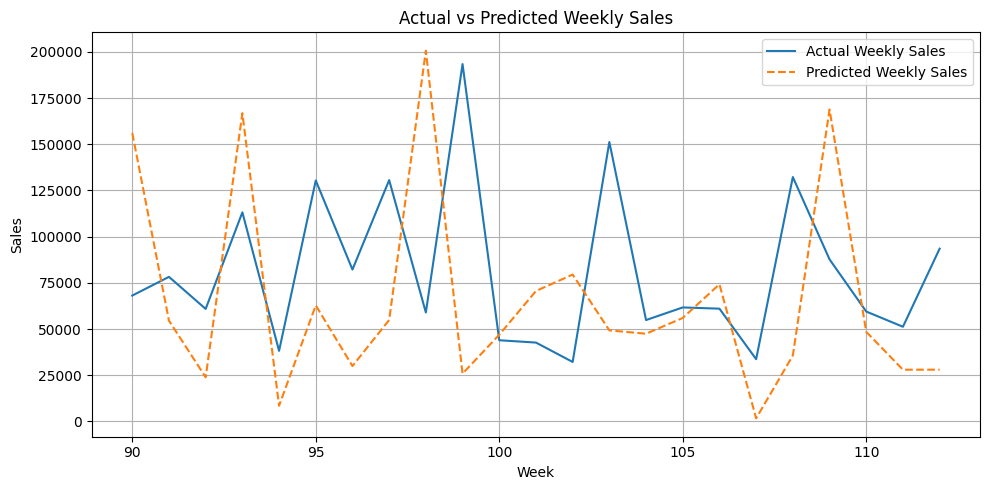

In [70]:
# Train XGBoost model for weekly prediction
model_xgb_weekly = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05)
model_xgb_weekly.fit(X_train_weekly, y_train_weekly)

# Predict sales for the test set
y_pred_weekly = model_xgb_weekly.predict(X_test_weekly)

# Plot predicted vs actual sales (weekly)
plt.figure(figsize=(10, 5))
plt.plot(y_test_weekly.index, y_test_weekly, label="Actual Weekly Sales")
plt.plot(y_test_weekly.index, y_pred_weekly, label="Predicted Weekly Sales", linestyle='--')
plt.title("Actual vs Predicted Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


In [60]:
# Aggregate sales data by month (monthly predictions)
daily_sales['month_id'] = daily_sales['ds'].dt.to_period('M')
monthly_sales = daily_sales.groupby('month_id', as_index=False)['y'].sum()

# Feature Engineering for monthly data
X_monthly = monthly_sales[['month_id']]
X_monthly['month'] = monthly_sales['month_id'].dt.month
X_monthly['year'] = monthly_sales['month_id'].dt.year
y_monthly = monthly_sales['y']

# Split into train and test sets for monthly prediction
X_train_monthly, X_test_monthly, y_train_monthly, y_test_monthly = train_test_split(X_monthly, y_monthly, test_size=0.2, shuffle=False)

# Preview the split shapes
X_train_monthly.shape, X_test_monthly.shape, y_train_monthly.shape, y_test_monthly.shape


((23, 3), (6, 3), (23,), (6,))

In [62]:
# Feature Engineering for monthly data
X_monthly = monthly_sales[['month_id']].copy()
X_monthly['month'] = monthly_sales['month_id'].dt.month
X_monthly['year'] = monthly_sales['month_id'].dt.year

# Drop 'month_id' as it is non-numeric
X_monthly = X_monthly.drop(columns=['month_id'])

# Define the target
y_monthly = monthly_sales['y']

# Split into train and test sets for monthly prediction
X_train_monthly, X_test_monthly, y_train_monthly, y_test_monthly = train_test_split(
    X_monthly, y_monthly, test_size=0.2, shuffle=False
)

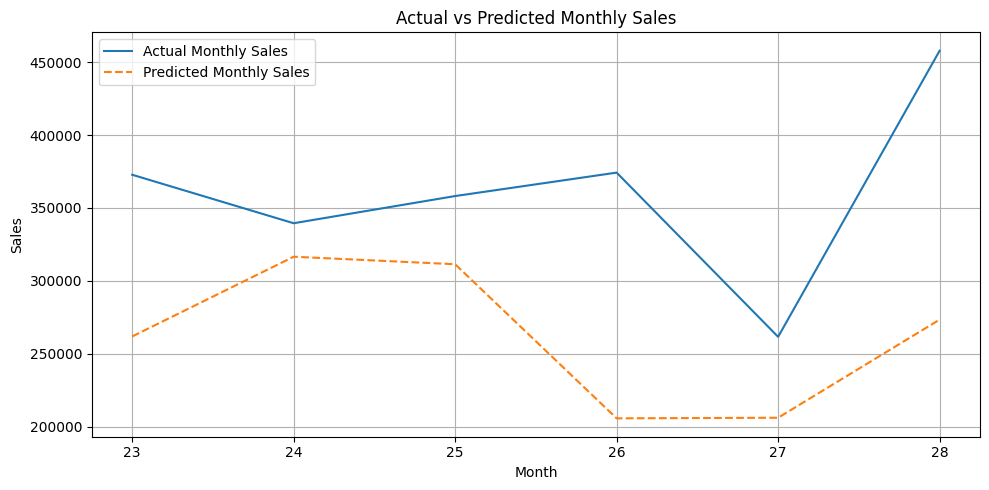

In [64]:
# Train XGBoost model for monthly prediction
model_xgb_monthly = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=1000, learning_rate=0.05)
model_xgb_monthly.fit(X_train_monthly, y_train_monthly)

# Predict sales for the test set
y_pred_monthly = model_xgb_monthly.predict(X_test_monthly)

# Plot predicted vs actual sales (monthly)
plt.figure(figsize=(10, 5))
plt.plot(y_test_monthly.index, y_test_monthly, label="Actual Monthly Sales")
plt.plot(y_test_monthly.index, y_pred_monthly, label="Predicted Monthly Sales", linestyle='--')
plt.title("Actual vs Predicted Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


C:\Users\HP\AppData\Local\Temp\ipykernel_9580\1413992075.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_months = pd.date_range(monthly_sales['month_id'].max().to_timestamp(), periods=3, freq='M')


[273437.75 286674.4  327144.7 ]


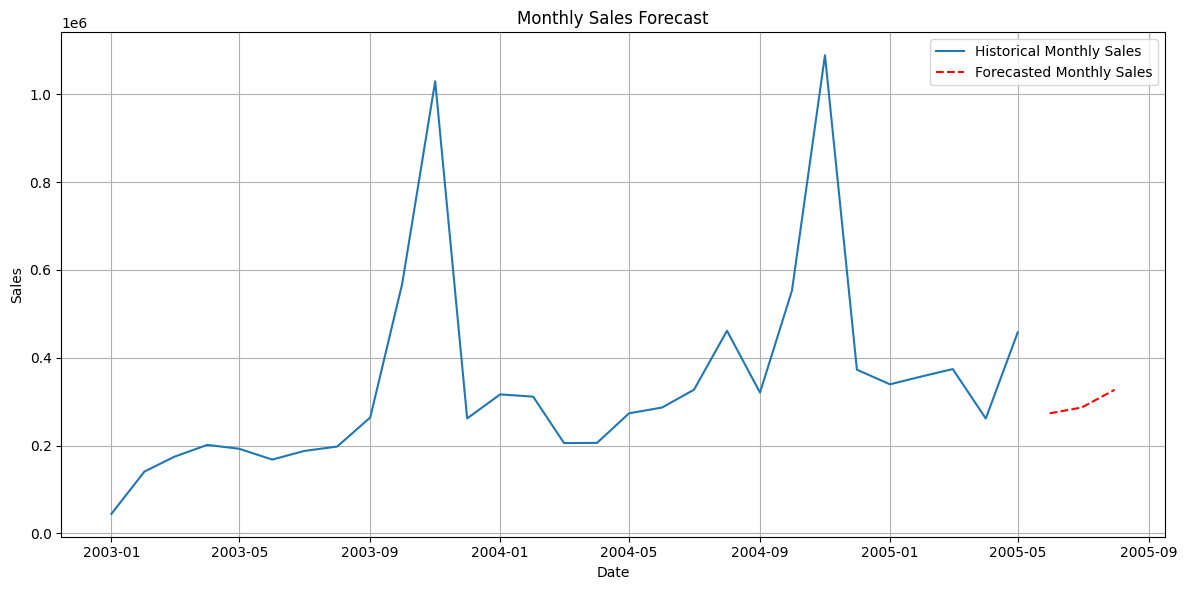

In [69]:
# Example: Create future dates for monthly predictions
future_months = pd.date_range(monthly_sales['month_id'].max().to_timestamp(), periods=3, freq='M')
future_monthly_features = pd.DataFrame({
    'month': future_months.month,
    'year': future_months.year
})

# Predict future monthly sales
future_sales_monthly = model_xgb_monthly.predict(future_monthly_features)

# Show predicted future monthly sales
print(future_sales_monthly)

# Plot future monthly sales predictions
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales['month_id'].dt.to_timestamp(), monthly_sales['y'], label="Historical Monthly Sales")
plt.plot(future_months, future_sales_monthly, label="Forecasted Monthly Sales", linestyle='--', color='red')    
plt.title("Monthly Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid()
plt.tight_layout()

plt.show()